# TransUNet K-Fold Cross-Validation Training

This notebook implements k-fold cross-validation training and metrics measurement for the **TransUNet model** with **MIFOCAT loss**.

## Overview

- **Model**: TransUNet (Transformer-based U-Net)
- **Loss**: MIFOCAT (MSE + Focal + Categorical Cross-Entropy)
- **Dataset**: ACDC 2017 Cardiac MRI
- **Validation**: 5-fold cross-validation

## Workflow

1. Setup and imports
2. Configure parameters
3. Data splitting (if needed)
4. K-fold training
5. Results aggregation
6. Visualization

## 1. Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")

Project root: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation
Python version: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
NumPy version: 1.24.3


In [2]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [3]:
try:
    import tensorflow as tf
    from tensorflow import keras
    print(f"TensorFlow version: {tf.__version__}")
    
    # Check for GPU availability
    if tf.config.list_physical_devices('GPU'):
        print(f"✓ GPU detected: {tf.config.list_physical_devices('GPU')}")
    else:
        print("⚠ No GPU detected. Using CPU.")
        print(f"  Available devices: {tf.config.list_physical_devices()}")
    
except ImportError as e:
    print(f"TensorFlow import failed: {e}")
    print("Install with: pip install tensorflow keras")

try:
    from split_data import CardiacDataSplitter
    from custom_datagen import FoldAwareDataLoader
    from train_kfold_wrapper import KFoldTrainer
    from transunet_model import build_transunet_mifocat, get_custom_objects
    print("✓ Custom modules imported successfully")
except ImportError as e:
    print(f"Custom module import failed: {e}")
    print("Ensure all required modules are in the project root.")

2026-01-28 10:56:11.921523: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 10:56:12.646574: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow version: 2.13.0
✓ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Custom modules imported successfully


## 2. Configuration

In [4]:
# ============ CONFIGURATION ============

# Data paths - ACDC2017 Dataset Structure
DATA_ROOT = Path.cwd() / "acdc2017" / "Data 2D" / "ED" / "Data Per Pasien Training 2D"
OUTPUT_DIR = Path.cwd() / "transunet_kfold_results"
OUTPUT_DIR.mkdir(exist_ok=True)

# K-Fold parameters
N_SPLITS = 5                    # Number of folds
VAL_RATIO = 0.1                 # Validation ratio per fold
RANDOM_SEED = 42

# Training parameters
MODEL_TYPE = "transunet"        # TransUNet model
EPOCHS_PER_FOLD = 50
BATCH_SIZE = 32
EARLY_STOP_PATIENCE = 10
IMAGE_SUBDIR = "images"         # Subdirectory for images within patient folders
MASK_SUBDIR = "groundtruth"     # Subdirectory for masks within patient folders (ACDC2017 uses 'groundtruth')

# Model checkpoint output
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Print configuration
print("=" * 60)
print("TRANSUNET K-FOLD TRAINING CONFIGURATION")
print("=" * 60)
print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Number of folds: {N_SPLITS}")
print(f"Validation ratio: {VAL_RATIO}")
print(f"Model type: {MODEL_TYPE}")
print(f"Epochs per fold: {EPOCHS_PER_FOLD}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE}")
print(f"Mask subdirectory: {MASK_SUBDIR}")
print("=" * 60)

TRANSUNET K-FOLD TRAINING CONFIGURATION
Data root: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/acdc2017/Data 2D/ED/Data Per Pasien Training 2D
Output directory: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results
Number of folds: 5
Validation ratio: 0.1
Model type: transunet
Epochs per fold: 50
Batch size: 32
Early stopping patience: 10
Mask subdirectory: groundtruth


## 3. Data Splitting (Optional)

If you haven't generated the k-fold metadata yet, run this cell. Otherwise, skip to the next section.

In [5]:
# ## Uncomment to generate k-fold split metadata
# ## This only needs to be run once

# splitter = CardiacDataSplitter(
#     input_folder=str(DATA_ROOT),
#     output_folder=str(OUTPUT_DIR)
# )

# print(f"\nExecuting k-fold split with n_splits={N_SPLITS}, val_ratio={VAL_RATIO}...")
# print(f"Data directory: {DATA_ROOT}")
# print(f"Data directory exists: {DATA_ROOT.exists()}")

# splitter.kfold_split(
#     n_splits=N_SPLITS,
#     val_ratio=VAL_RATIO
# )
# print("✓ K-fold split complete")

## 4. Initialize K-Fold Trainer

In [6]:
# Path to k-fold metadata (generated by split_data.py or above cell)
FOLD_METADATA_PATH = OUTPUT_DIR / "kfold_metadata.json"

if not FOLD_METADATA_PATH.exists():
    print(f"✗ ERROR: Fold metadata not found: {FOLD_METADATA_PATH}")
    print("Run the data splitting step first or provide existing metadata.")
else:
    print(f"✓ Fold metadata found: {FOLD_METADATA_PATH}")
    
    # Initialize trainer
    trainer = KFoldTrainer(
        fold_metadata_path=str(FOLD_METADATA_PATH),
        base_data_dir=str(DATA_ROOT),
        output_dir=str(OUTPUT_DIR),
        seed=RANDOM_SEED
    )
    
    print("✓ KFoldTrainer initialized successfully")

✓ Fold metadata found: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/kfold_metadata.json
[KFoldTrainer] Loaded metadata for 5-fold CV
[KFoldTrainer] Output directory: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results
[KFoldTrainer] Initializing data loader...
[KFoldTrainer] Base data directory: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/acdc2017/Data 2D/ED/Data Per Pasien Training 2D
[KFoldTrainer] Base data directory exists: True
✓ KFoldTrainer initialized successfully


## 5. Run K-Fold Training

This will train the TransUNet model on all folds and save checkpoints + metrics.

In [ ]:
# Run k-fold cross-validation
print("\n🚀 Starting k-fold cross-validation training for TransUNet...\n")

results = trainer.run_all_folds(
    model_type=MODEL_TYPE,
    epochs=EPOCHS_PER_FOLD,
    batch_size=BATCH_SIZE,
    train_only=False,  # Set to True to skip test evaluation
    start_fold=0       # Set to resume from a specific fold
)

print("\n✓ K-fold cross-validation completed!")


🚀 Starting k-fold cross-validation training for TransUNet...


######################################################################
# K-FOLD CROSS-VALIDATION: 5 Folds
# Metadata: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/kfold_metadata.json
# Data dir: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/acdc2017/Data 2D/ED/Data Per Pasien Training 2D
# Output dir: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results
# Model type: transunet
# Starting from fold: 0
# Started: 2026-01-28 10:56:16
######################################################################

[KFoldTrainer] Loading TransUNet model with MIFOCAT loss...


2026-01-28 10:56:16.412193: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


[KFoldTrainer] TransUNet model compiled with MIFOCAT loss

[FOLD 0] Starting training
[FOLD 0] Loading data generators...

[FoldAwareDataLoader.get_generators] ===== STARTING FOLD 0 =====
[FoldAwareDataLoader.get_generators] Image subdir: images, Mask subdir: groundtruth
[FoldAwareDataLoader.get_generators] Target size: (256, 256)
[FoldAwareDataLoader.get_generators] Base directory: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/acdc2017/Data 2D/ED/Data Per Pasien Training 2D
[FoldAwareDataLoader] Fold 0: 72 train patients, 20 val patients
[FoldAwareDataLoader] Train patients: ['1', '10', '11', '12', '13']...
[FoldAwareDataLoader] Val patients: ['16', '17', '2', '27', '29']...
[FoldAwareDataLoader.get_file_list] Starting file list collection
[FoldAwareDataLoader.get_file_list] Base directory: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/acdc2017/Data 2D/ED/Data Per Pasien Training 2D
[FoldAwareDataLoader.get_file_list] Base directory exists: True
[FoldAwareDataLoader.

2026-01-28 10:56:27.974251: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2026-01-28 10:56:32.056052: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-01-28 10:56:37.833352: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fb13c127e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-28 10:56:37.833382: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-01-28 10:56:37.837437: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-28 10:56:37.939670: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 [==============================] - ETA: 0s - loss: 0.4492 - accuracy: 0.9415 - mean_iou: 0.8325 - dice_score: 0.8839
Epoch 1: val_loss improved from inf to 70.68443, saving model to /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/fold_0/fold_0_best_model.h5


/home/ubuntu/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


21/21 [==============================] - 85s 2s/step - loss: 0.4492 - accuracy: 0.9415 - mean_iou: 0.8325 - dice_score: 0.8839 - val_loss: 70.6844 - val_accuracy: 0.0117 - val_mean_iou: 0.0060 - val_dice_score: 0.0119
Epoch 2/50
21/21 [==============================] - ETA: 0s - loss: 0.1353 - accuracy: 0.9983 - mean_iou: 0.9553 - dice_score: 0.9771
Epoch 2: val_loss did not improve from 70.68443
21/21 [==============================] - 23s 1s/step - loss: 0.1353 - accuracy: 0.9983 - mean_iou: 0.9553 - dice_score: 0.9771 - val_loss: 170.2985 - val_accuracy: 0.2589 - val_mean_iou: 0.1448 - val_dice_score: 0.2529
Epoch 3/50
13/21 [=================>............] - ETA: 8s - loss: 0.0986 - accuracy: 0.9977 - mean_iou: 0.9607 - dice_score: 0.9799

## 6. Results Analysis

In [13]:
# Load and display aggregated results
aggregated_results_path = OUTPUT_DIR / "aggregated_results.json"
fold_results_path = OUTPUT_DIR / "fold_results.json"

if aggregated_results_path.exists():
    with open(aggregated_results_path, 'r') as f:
        aggregated = json.load(f)
    
    print("\n" + "="*60)
    print("AGGREGATED RESULTS (ACROSS ALL FOLDS)")
    print("="*60)
    for key, value in aggregated.items():
        if isinstance(value, float):
            print(f"{key:.<40} {value:.6f}")
        else:
            print(f"{key:.<40} {value}")
    print("="*60)

if fold_results_path.exists():
    with open(fold_results_path, 'r') as f:
        fold_results = json.load(f)
    
    # Create DataFrame for easier visualization
    df = pd.DataFrame(fold_results)
    print("\n" + "="*60)
    print("PER-FOLD RESULTS")
    print("="*60)
    print(df.to_string(index=False))
    print("="*60)


AGGREGATED RESULTS (ACROSS ALL FOLDS)
n_folds_completed....................... 5
n_folds_total........................... 5
val_loss_mean........................... 0.048019
val_loss_std............................ 0.033532
val_loss_min............................ 0.022705
val_loss_max............................ 0.114294

PER-FOLD RESULTS
 fold_id  final_loss  final_val_loss  best_val_loss  epochs_trained                                                                                                 checkpoint
       0    0.021114        0.114294       0.012596              37 /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/fold_0/fold_0_best_model.h5
       1    0.026025        0.029950       0.011616              27 /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/fold_1/fold_1_best_model.h5
       2    0.019482        0.036634       0.018143              41 /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet

## 7. Visualization

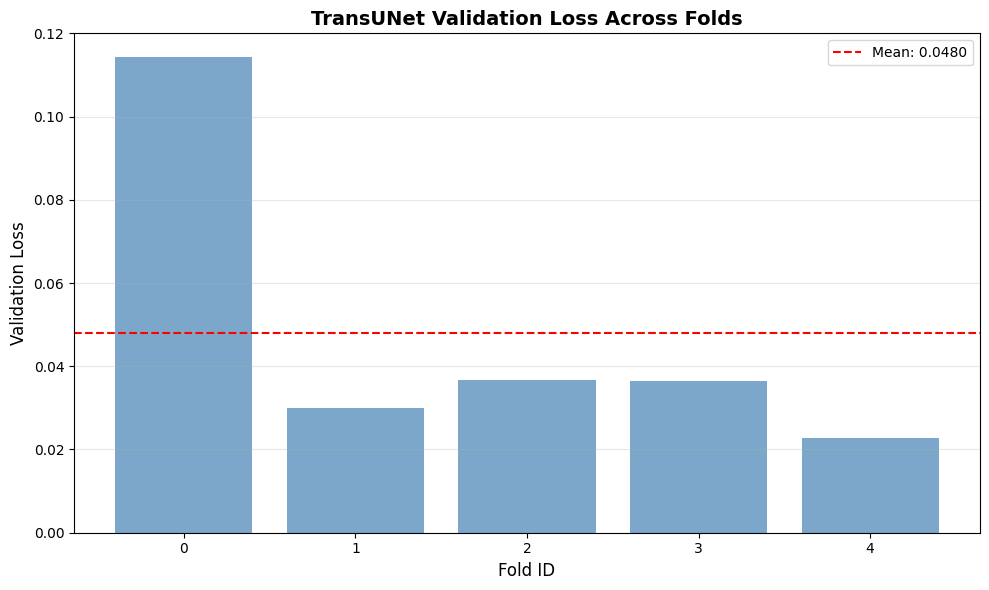


✓ Visualization saved to: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/transunet_validation_loss.png


In [14]:
# Visualize validation loss across folds
if fold_results_path.exists():
    with open(fold_results_path, 'r') as f:
        fold_results = json.load(f)
    
    val_losses = [r.get('final_val_loss') for r in fold_results if r.get('final_val_loss')]
    fold_ids = [r.get('fold_id') for r in fold_results if r.get('final_val_loss')]
    
    if val_losses:
        plt.figure(figsize=(10, 6))
        plt.bar(fold_ids, val_losses, color='steelblue', alpha=0.7)
        plt.axhline(y=np.mean(val_losses), color='red', linestyle='--', label=f'Mean: {np.mean(val_losses):.4f}')
        plt.xlabel('Fold ID', fontsize=12)
        plt.ylabel('Validation Loss', fontsize=12)
        plt.title('TransUNet Validation Loss Across Folds', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'transunet_validation_loss.png', dpi=300)
        plt.show()
        
        print(f"\n✓ Visualization saved to: {OUTPUT_DIR / 'transunet_validation_loss.png'}")

## 8. Load and Test a Specific Fold Model

In [15]:
# Example: Load best model from fold 0
fold_id = 0
model_path = OUTPUT_DIR / f"fold_{fold_id}" / f"fold_{fold_id}_best_model.h5"

if model_path.exists():
    print(f"Loading model from: {model_path}")
    
    # Load with custom objects
    custom_objs = get_custom_objects()
    model = keras.models.load_model(str(model_path), custom_objects=custom_objs, compile=False)
    
    print("✓ Model loaded successfully")
    print(f"\nModel summary:")
    model.summary()
else:
    print(f"✗ Model not found: {model_path}")

Loading model from: /home/ubuntu/mifocat-retrain/Code-Cardiac-Segmentation/transunet_kfold_results/fold_0/fold_0_best_model.h5
✓ Model loaded successfully

Model summary:
Model: "TransUNet_MIFOCAT"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 enc1_conv1 (Conv2D)         (None, 256, 256, 64)         640       ['input[0][0]']               
                                                                                                  
 enc1_bn1 (BatchNormalizati  (None, 256, 256, 64)         256       ['enc1_conv1[0][0]']          
 on)                                                                                              
          

## Summary

This notebook implements k-fold cross-validation training for TransUNet with MIFOCAT loss, mirroring the workflow from `train_kfold_notebook.ipynb` but specifically for the TransUNet architecture.

**Key features:**
- TransUNet model with transformer layers
- MIFOCAT unified loss function
- 5-fold cross-validation
- Per-fold checkpointing
- Aggregated metrics across folds
- Results visualization

**Next steps:**
1. Run detailed evaluation metrics (Dice, IoU, Hausdorff, MCC) on test sets
2. Compare TransUNet results with U-Net baseline
3. Generate prediction visualizations
4. Statistical significance testing